<a href="https://colab.research.google.com/github/JEAN-hub-lab/APPENDING-JOINING/blob/main/Chapter_7_APPENDING_%26_JOINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

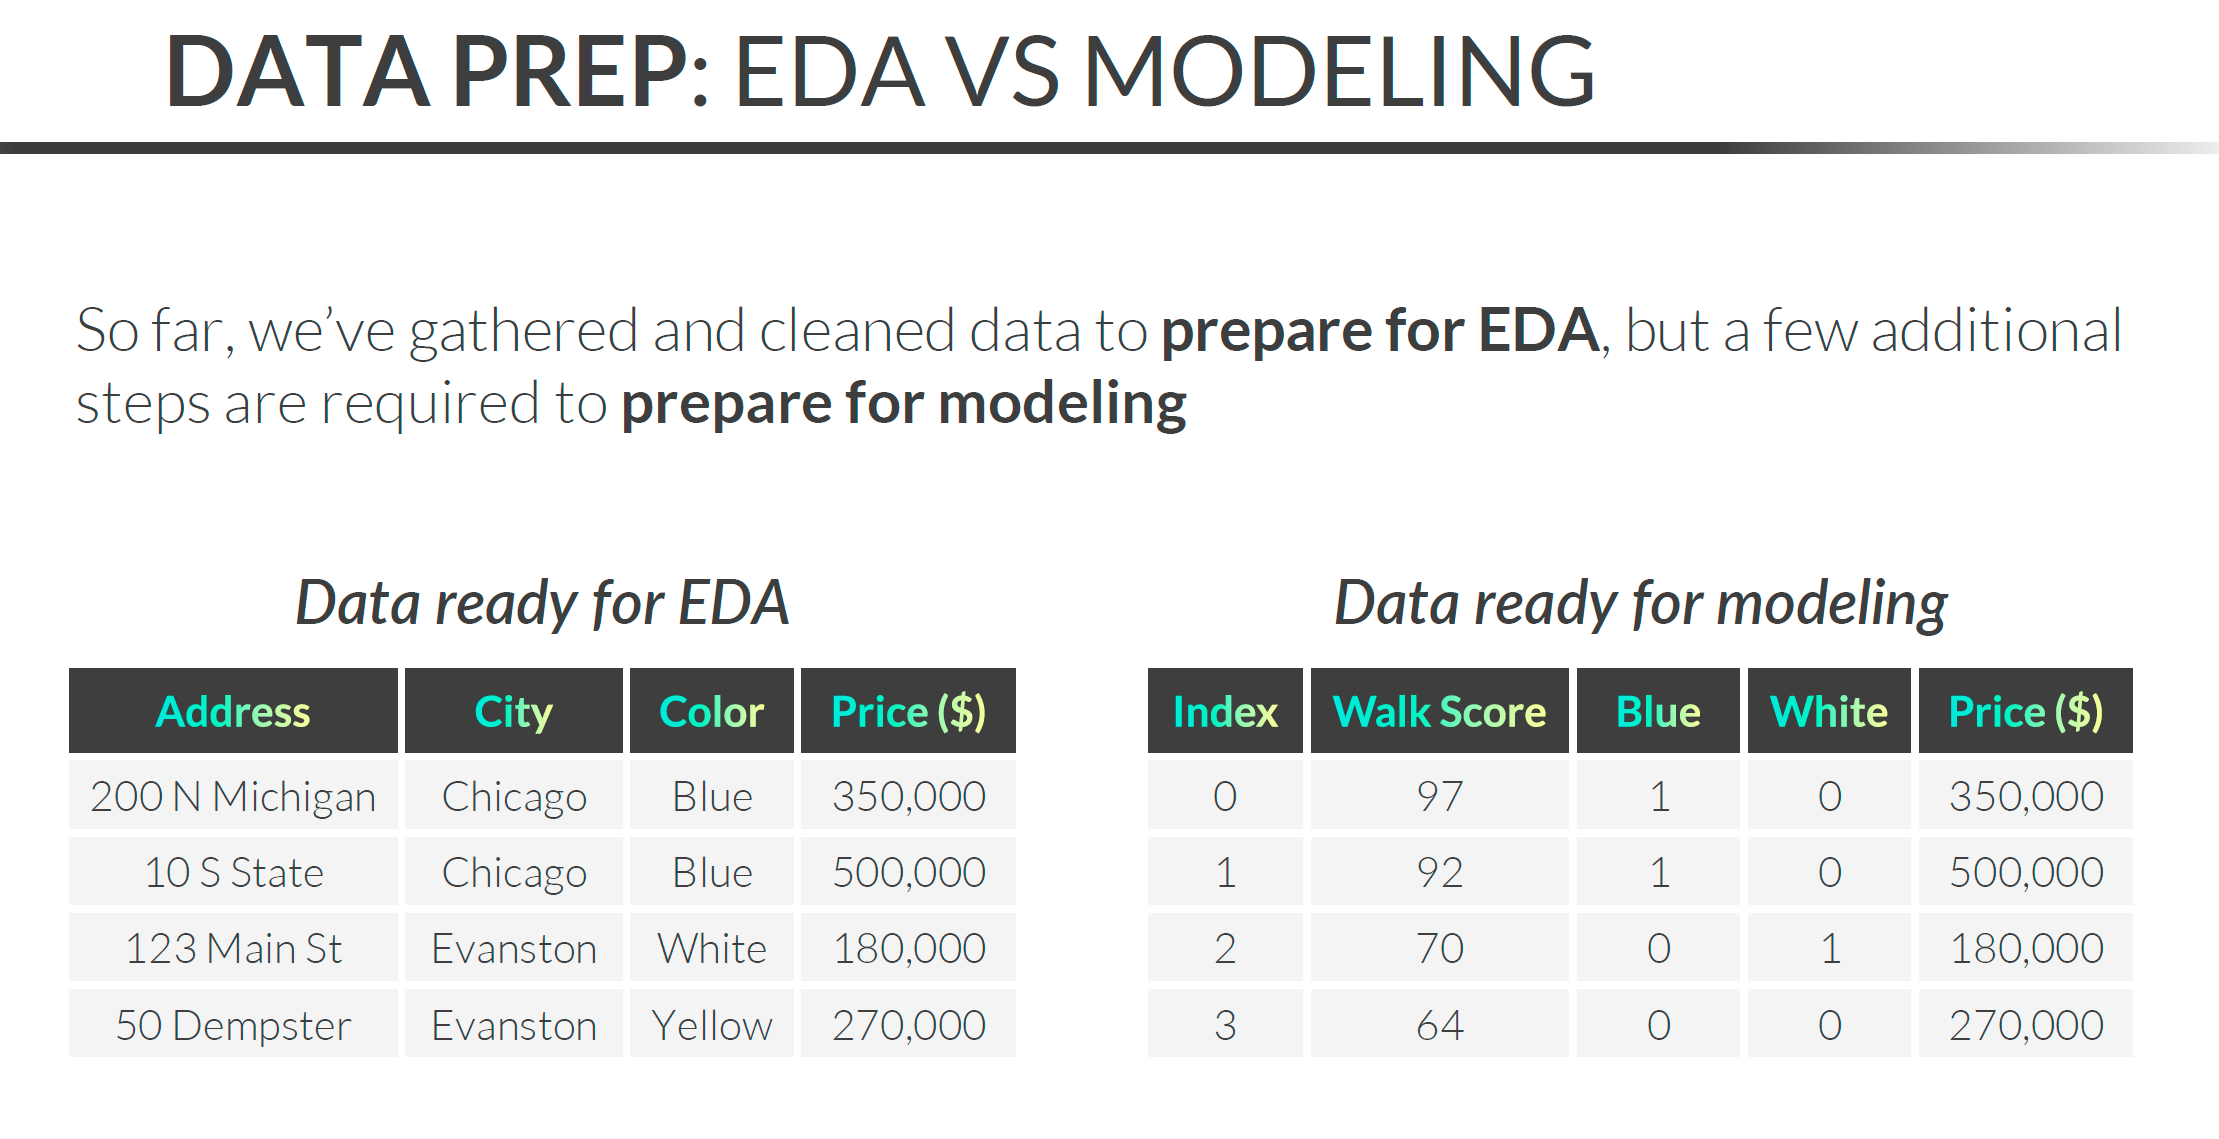

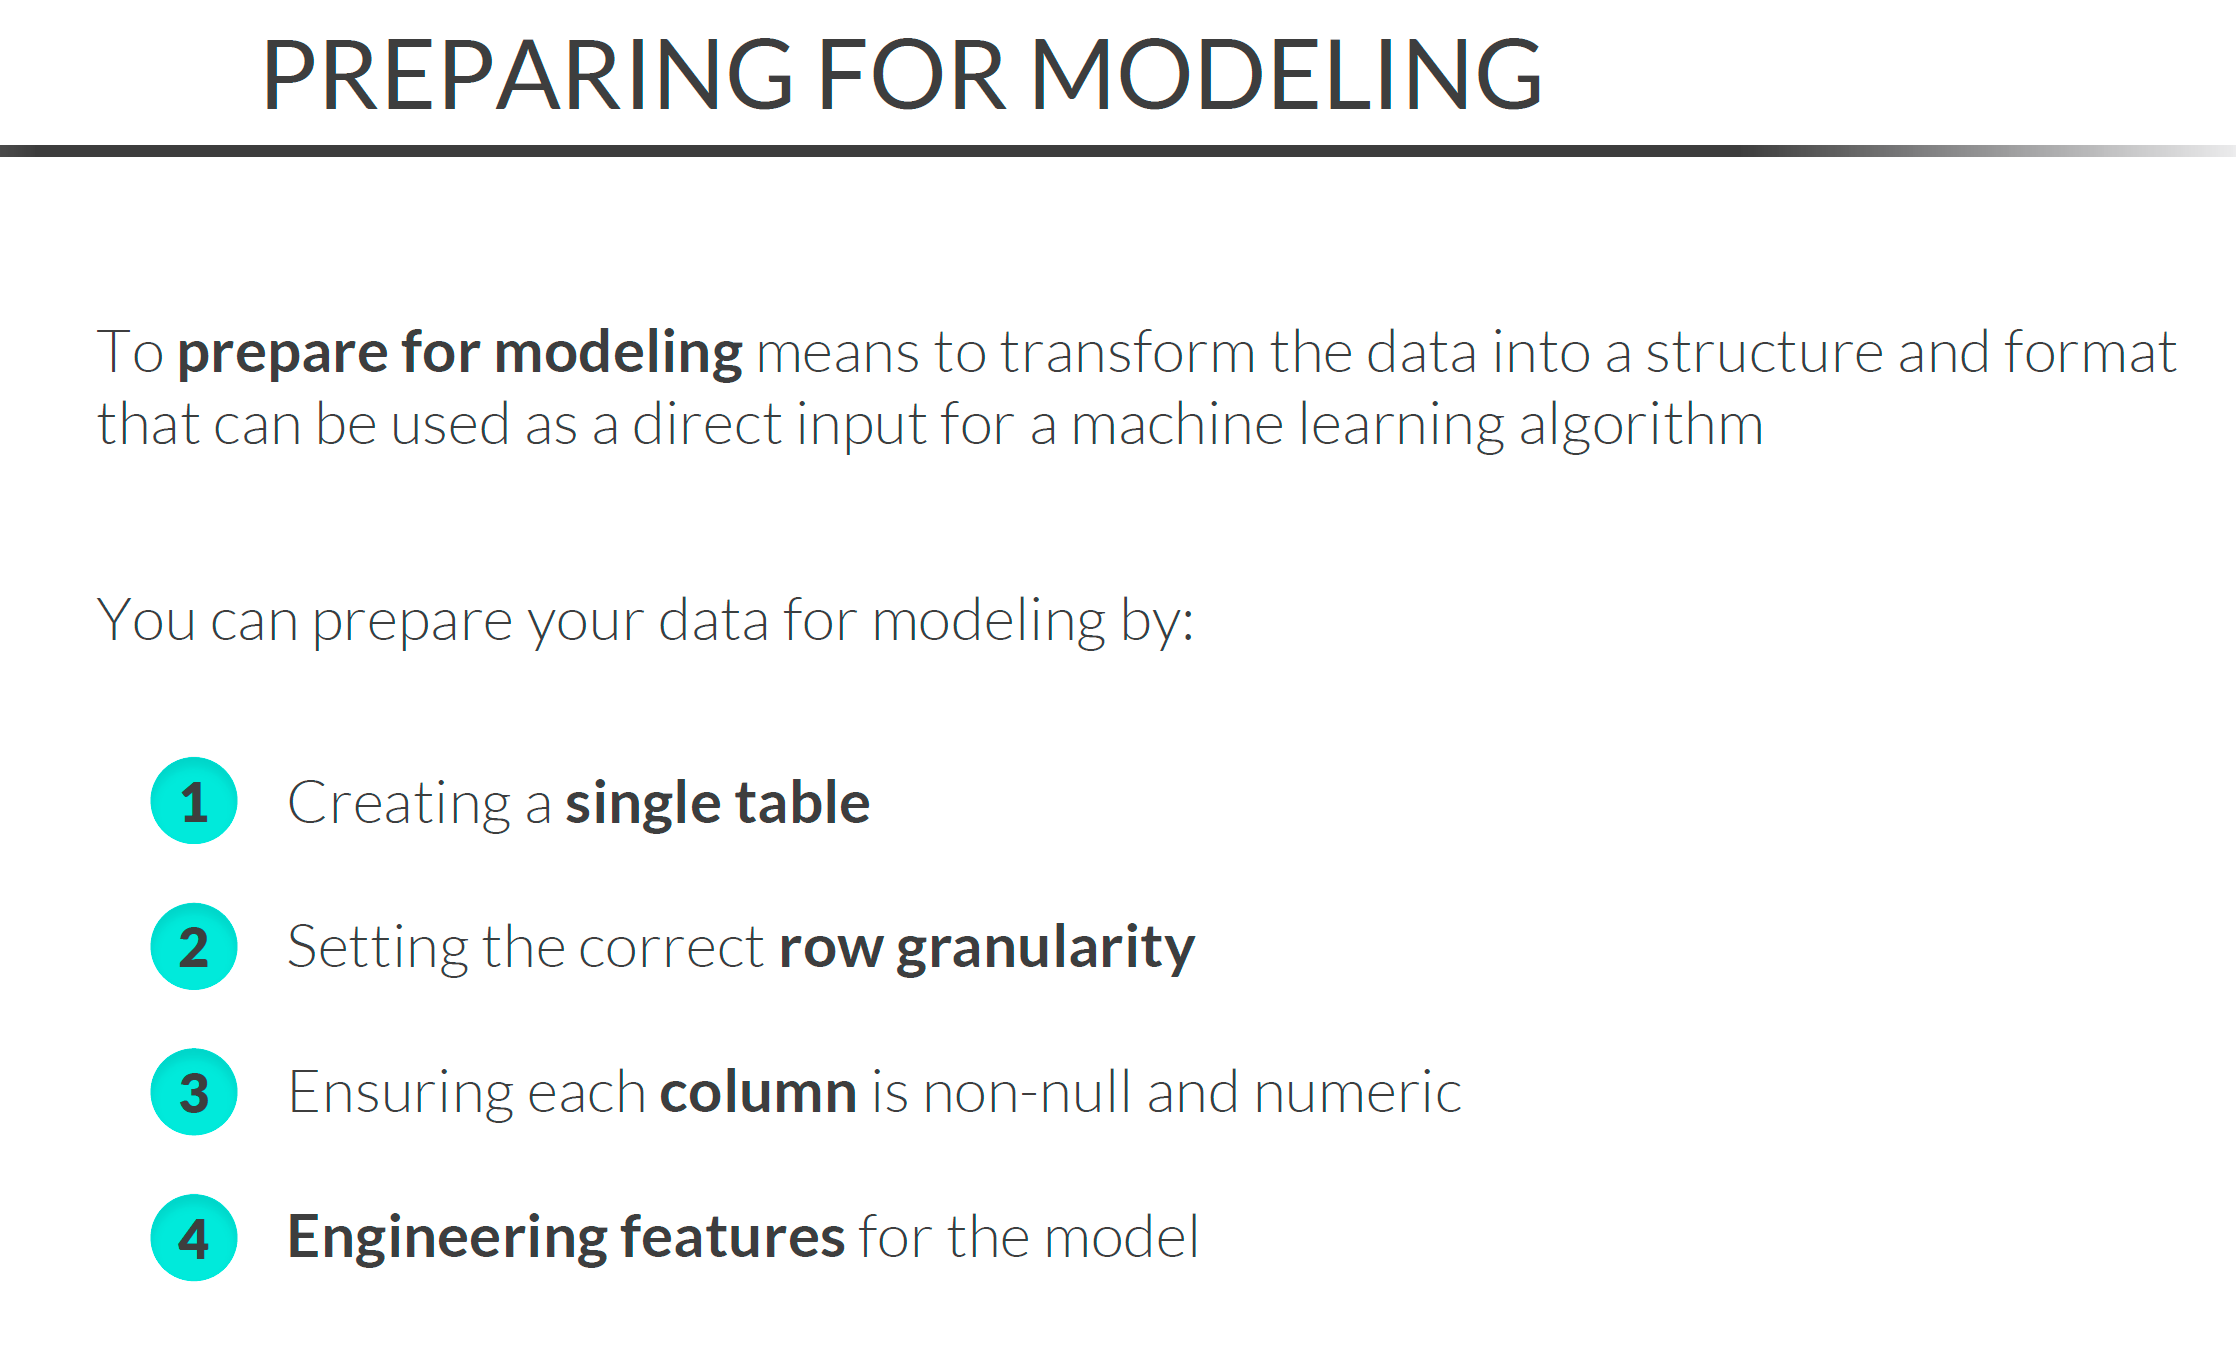

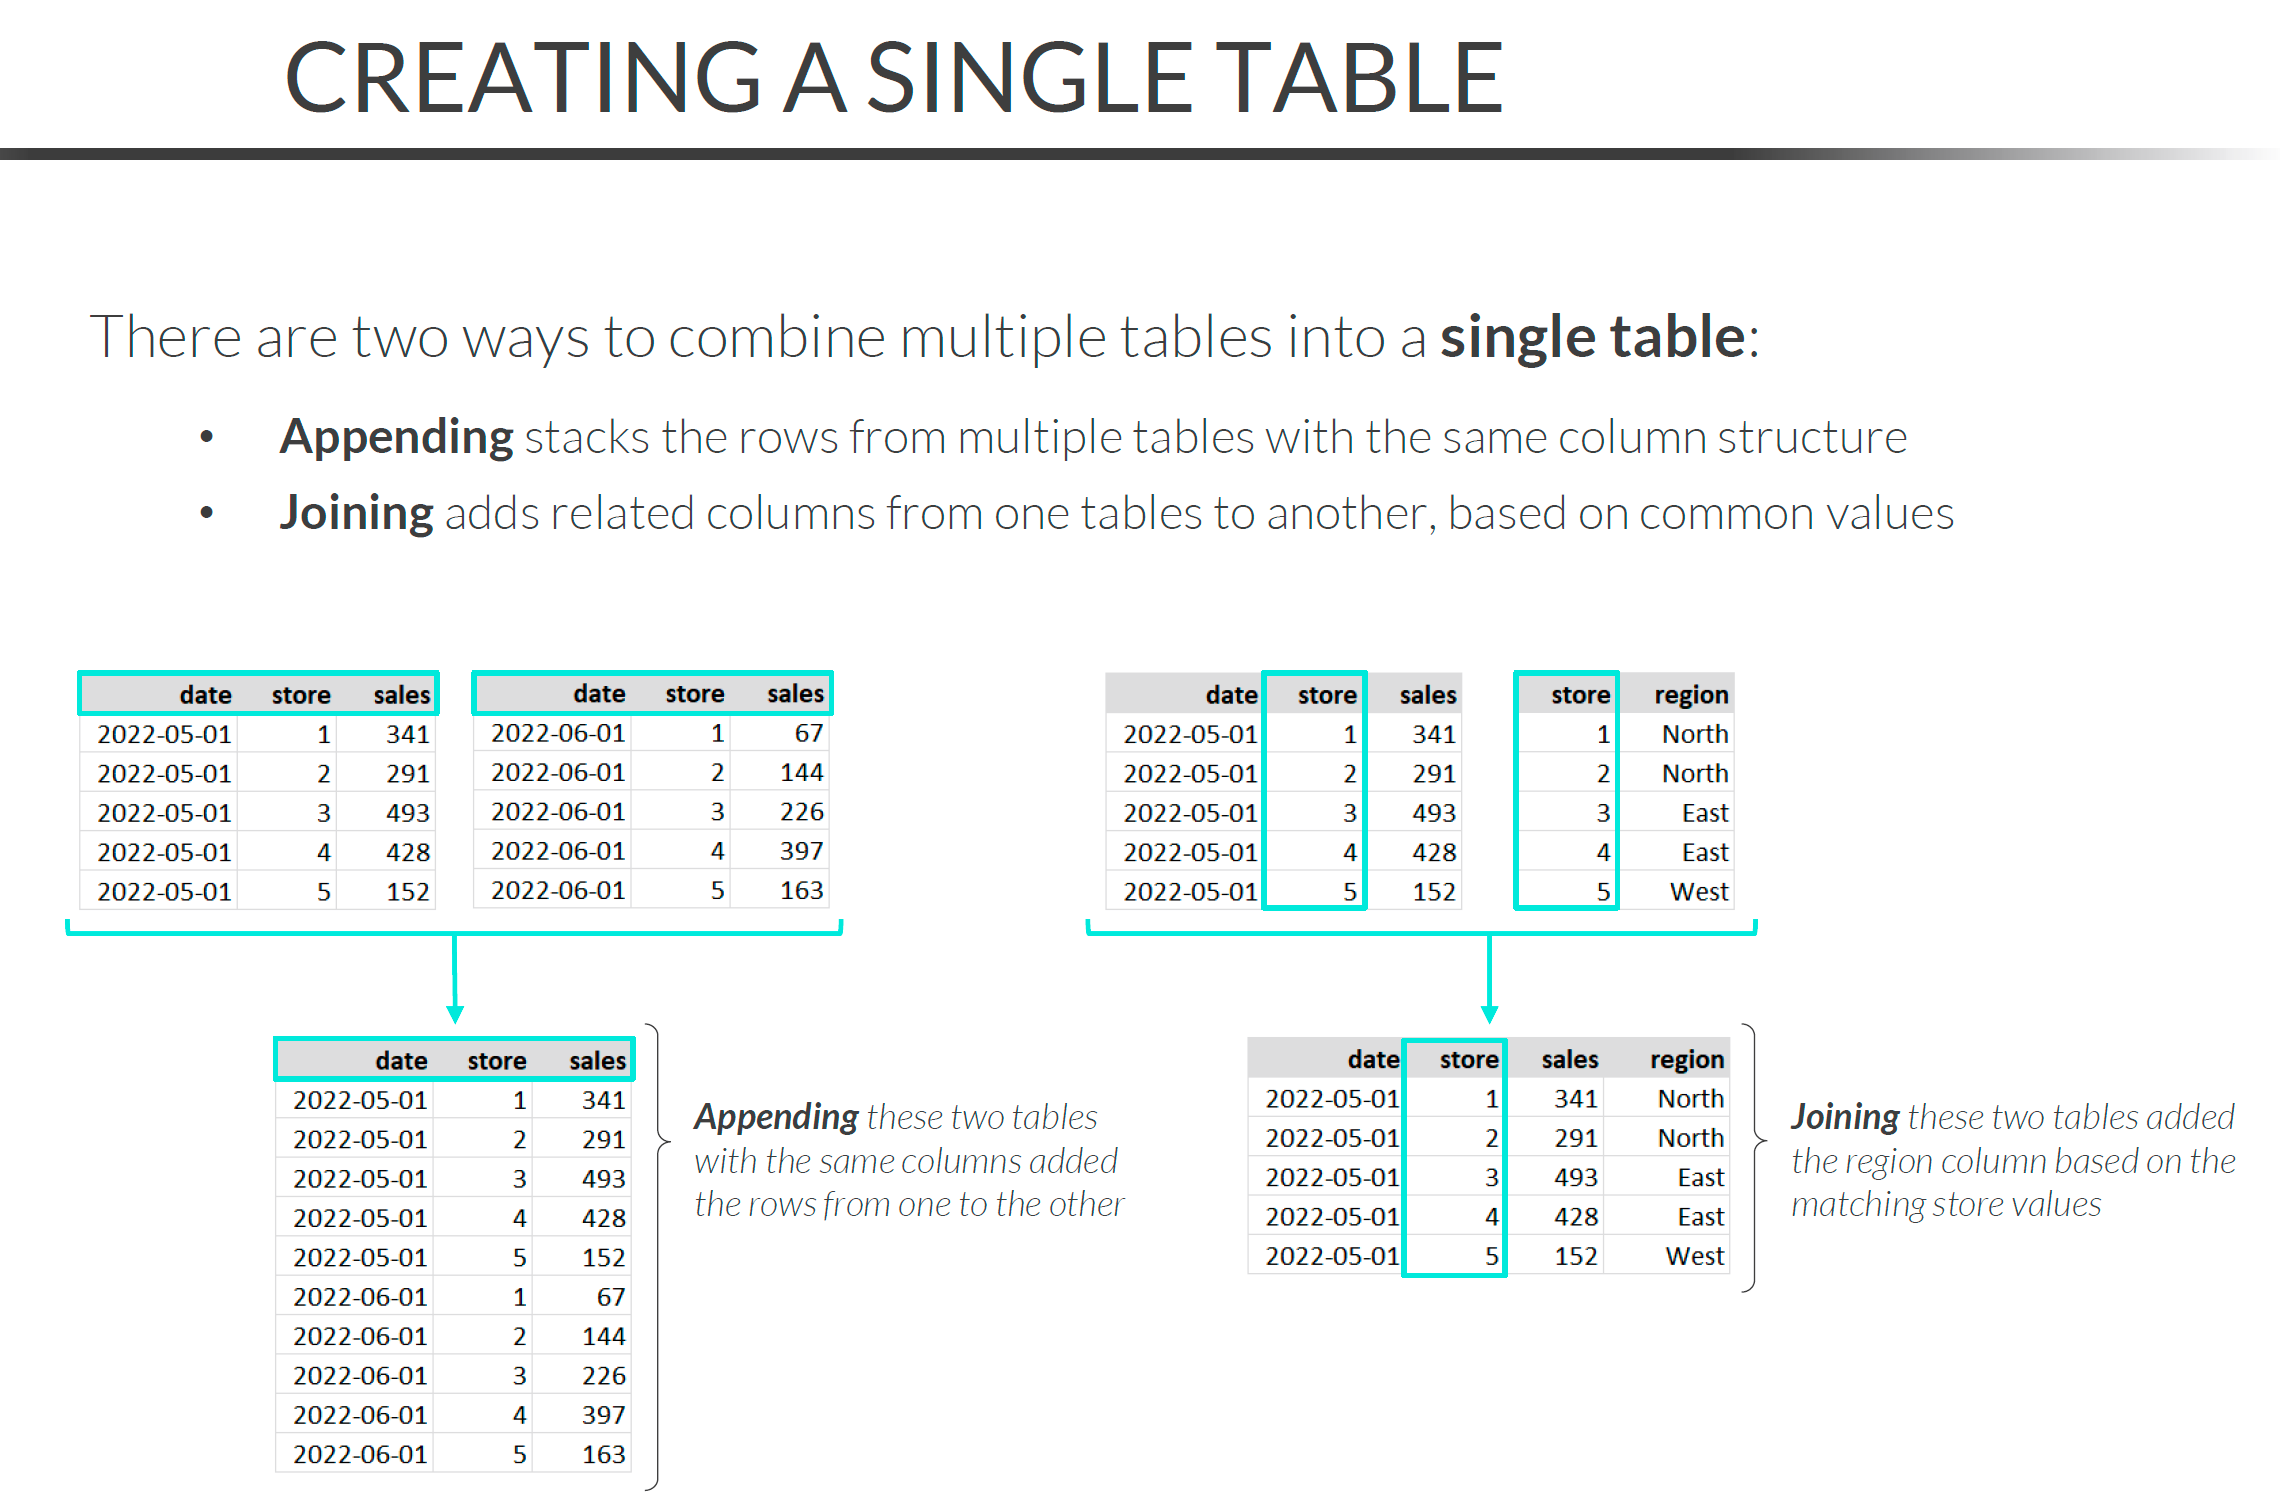

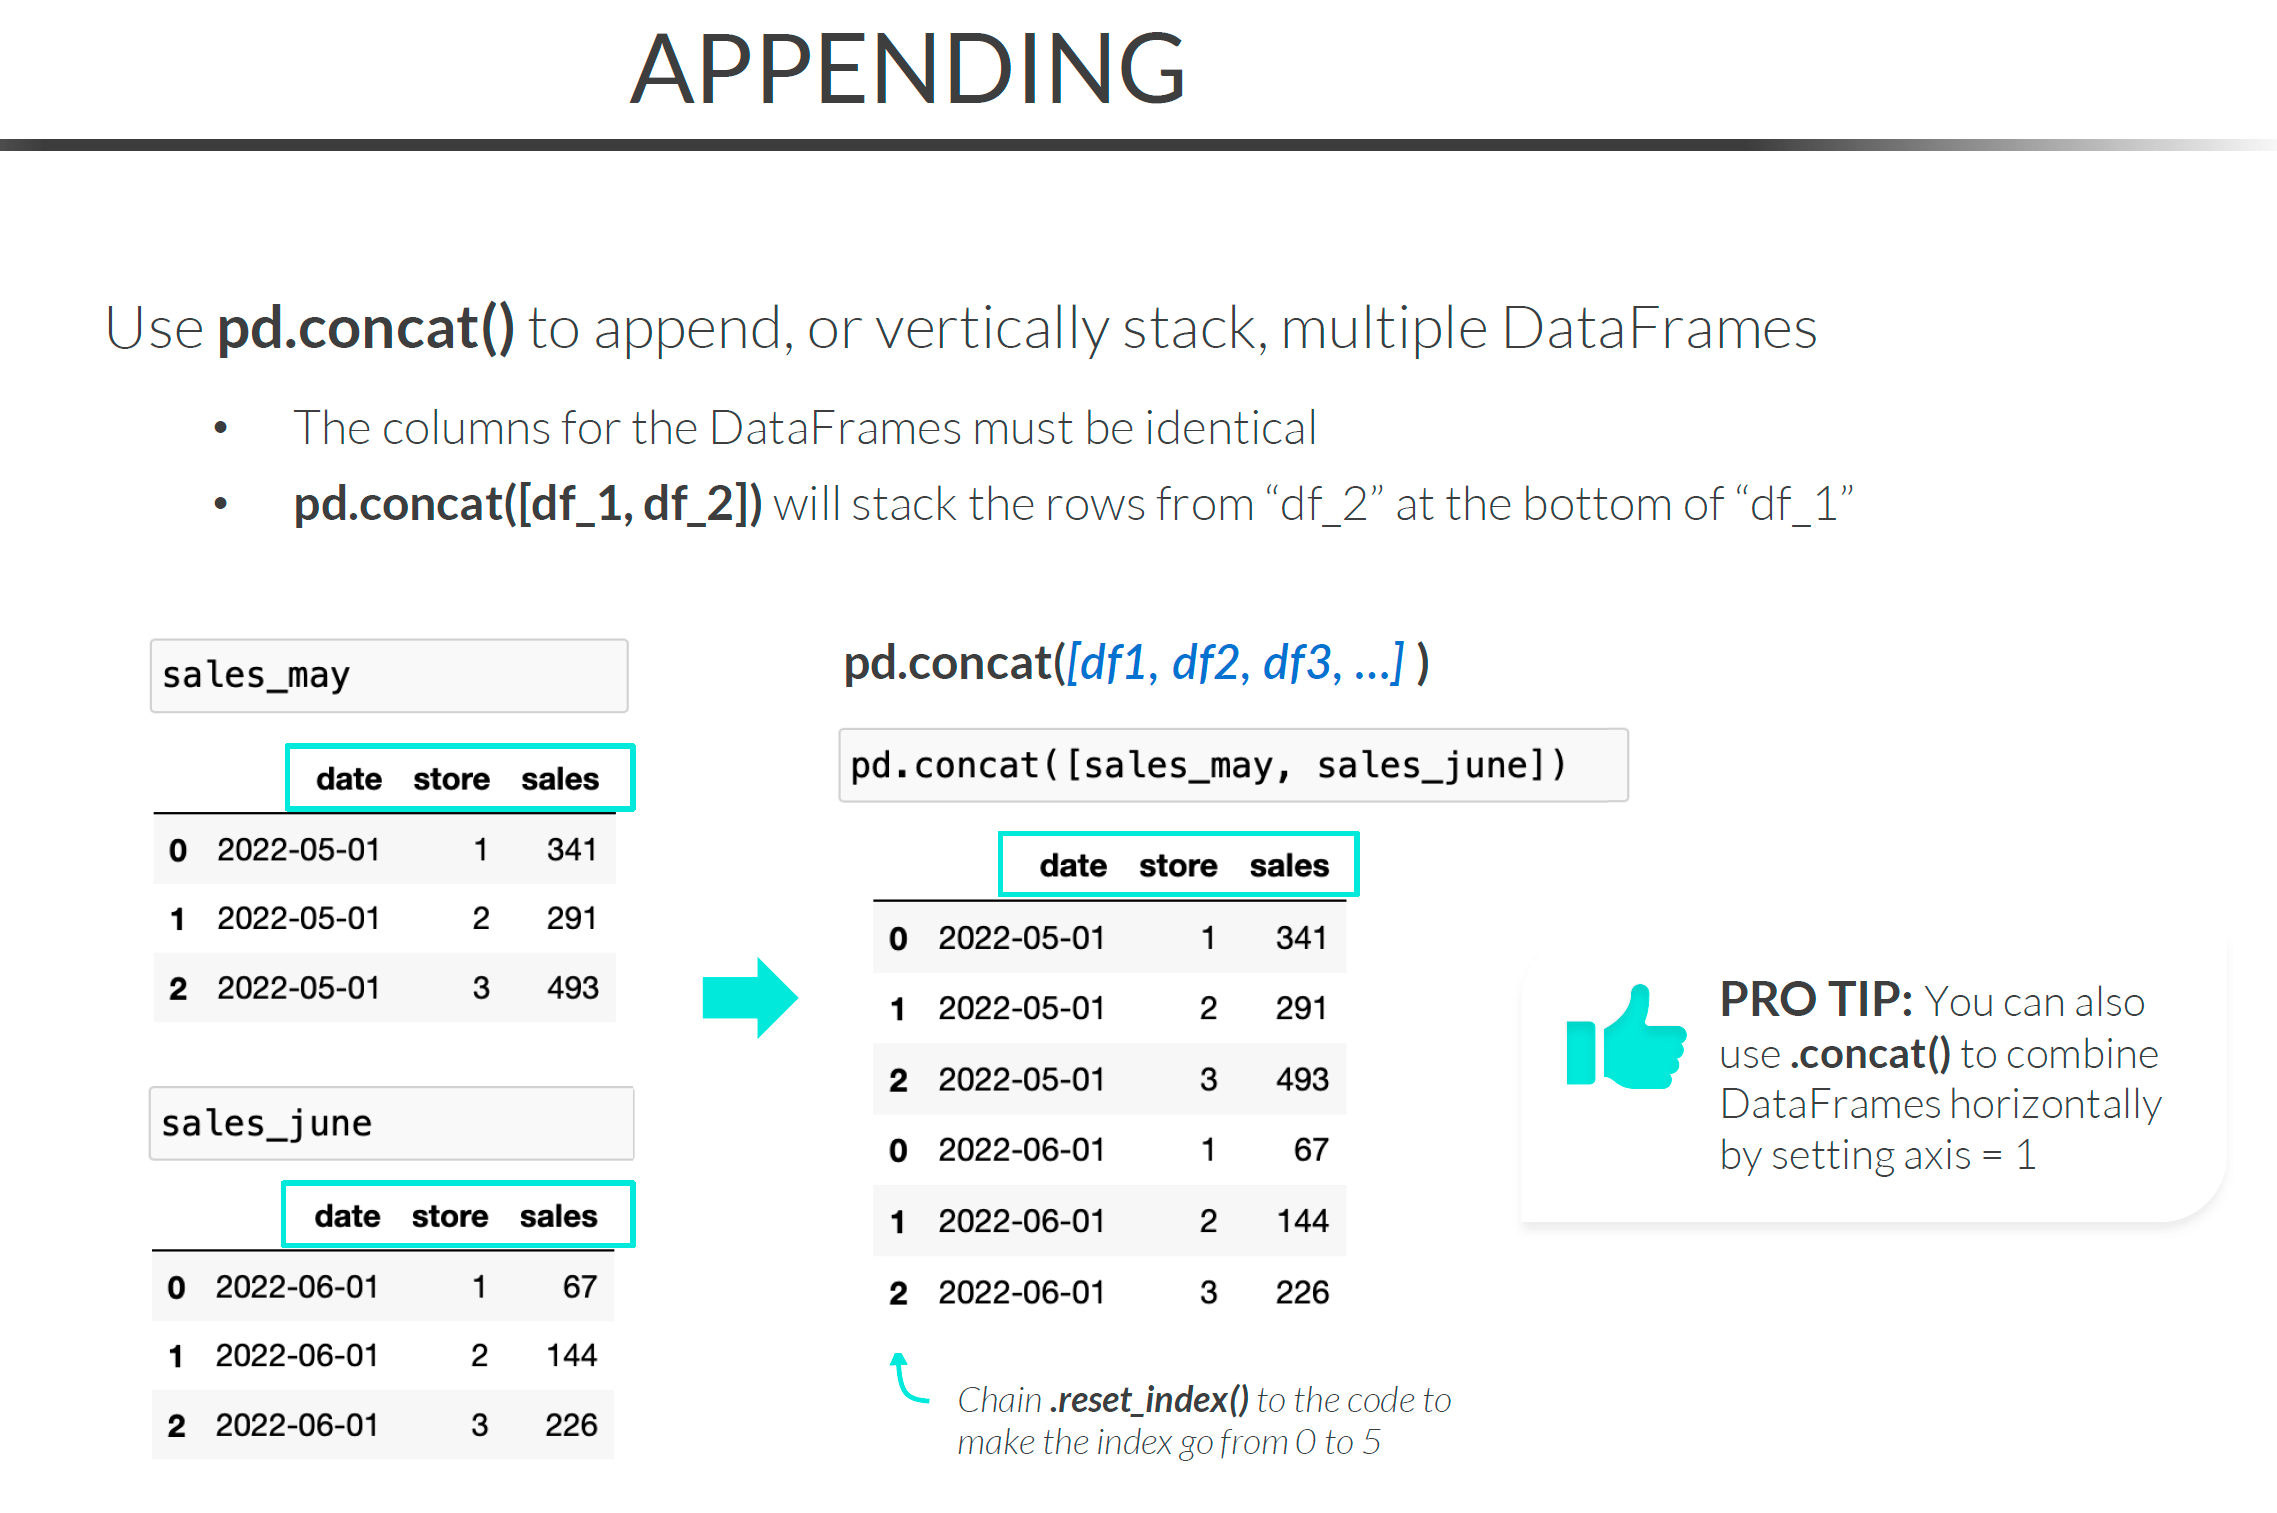

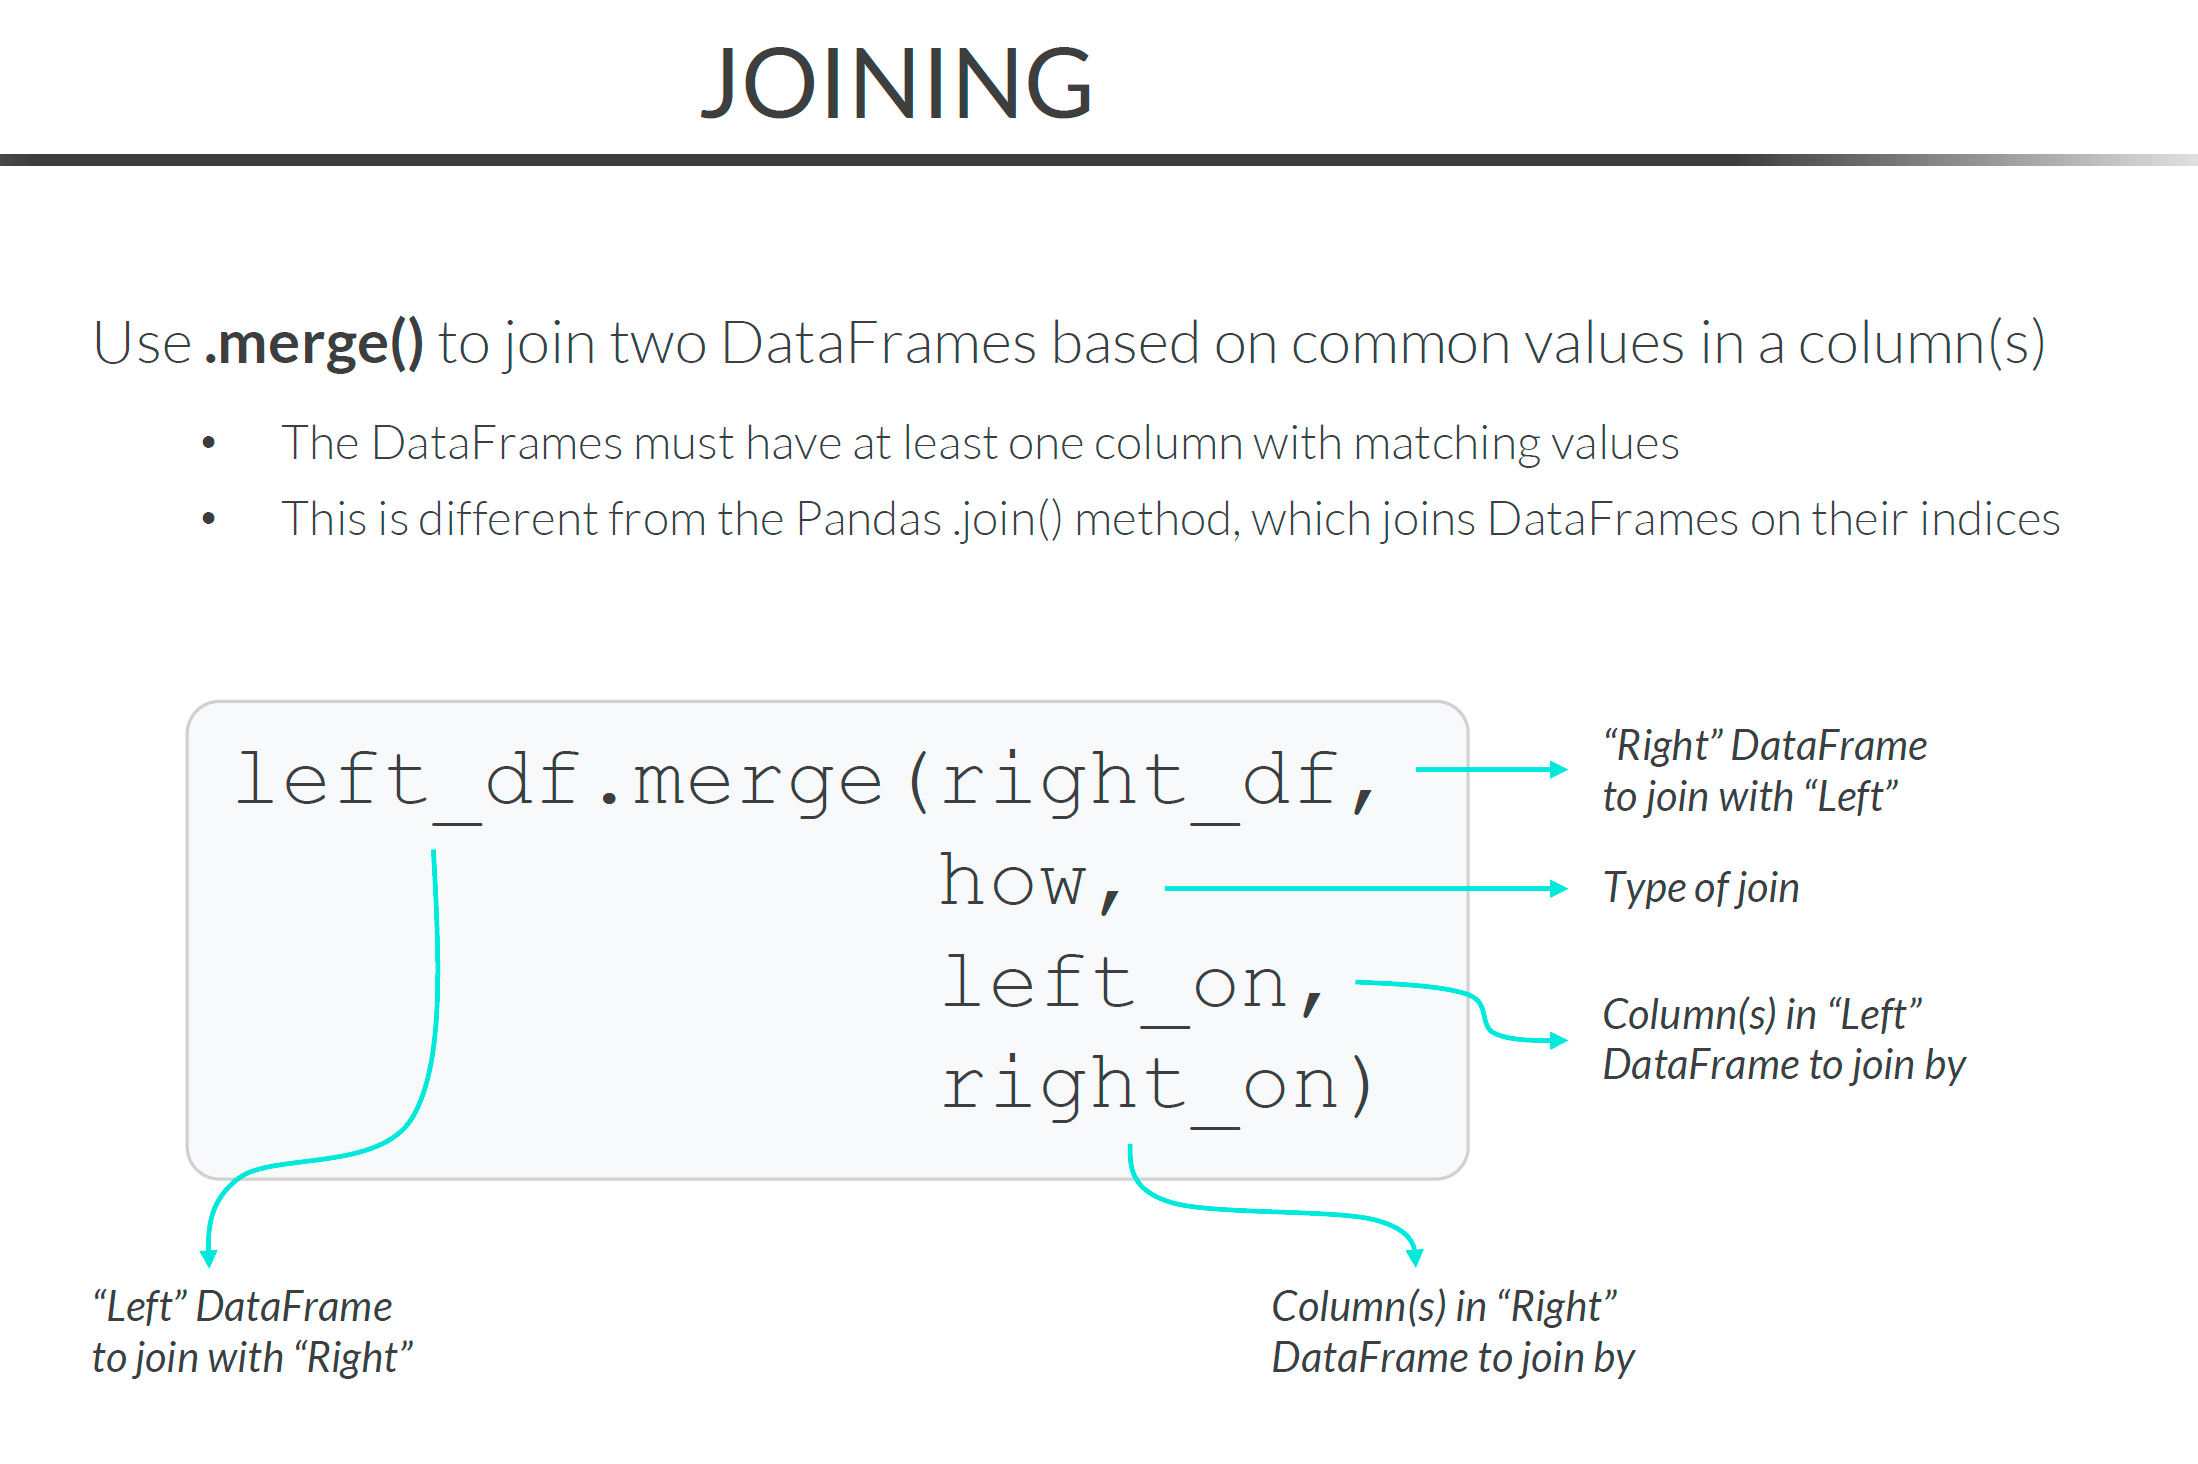

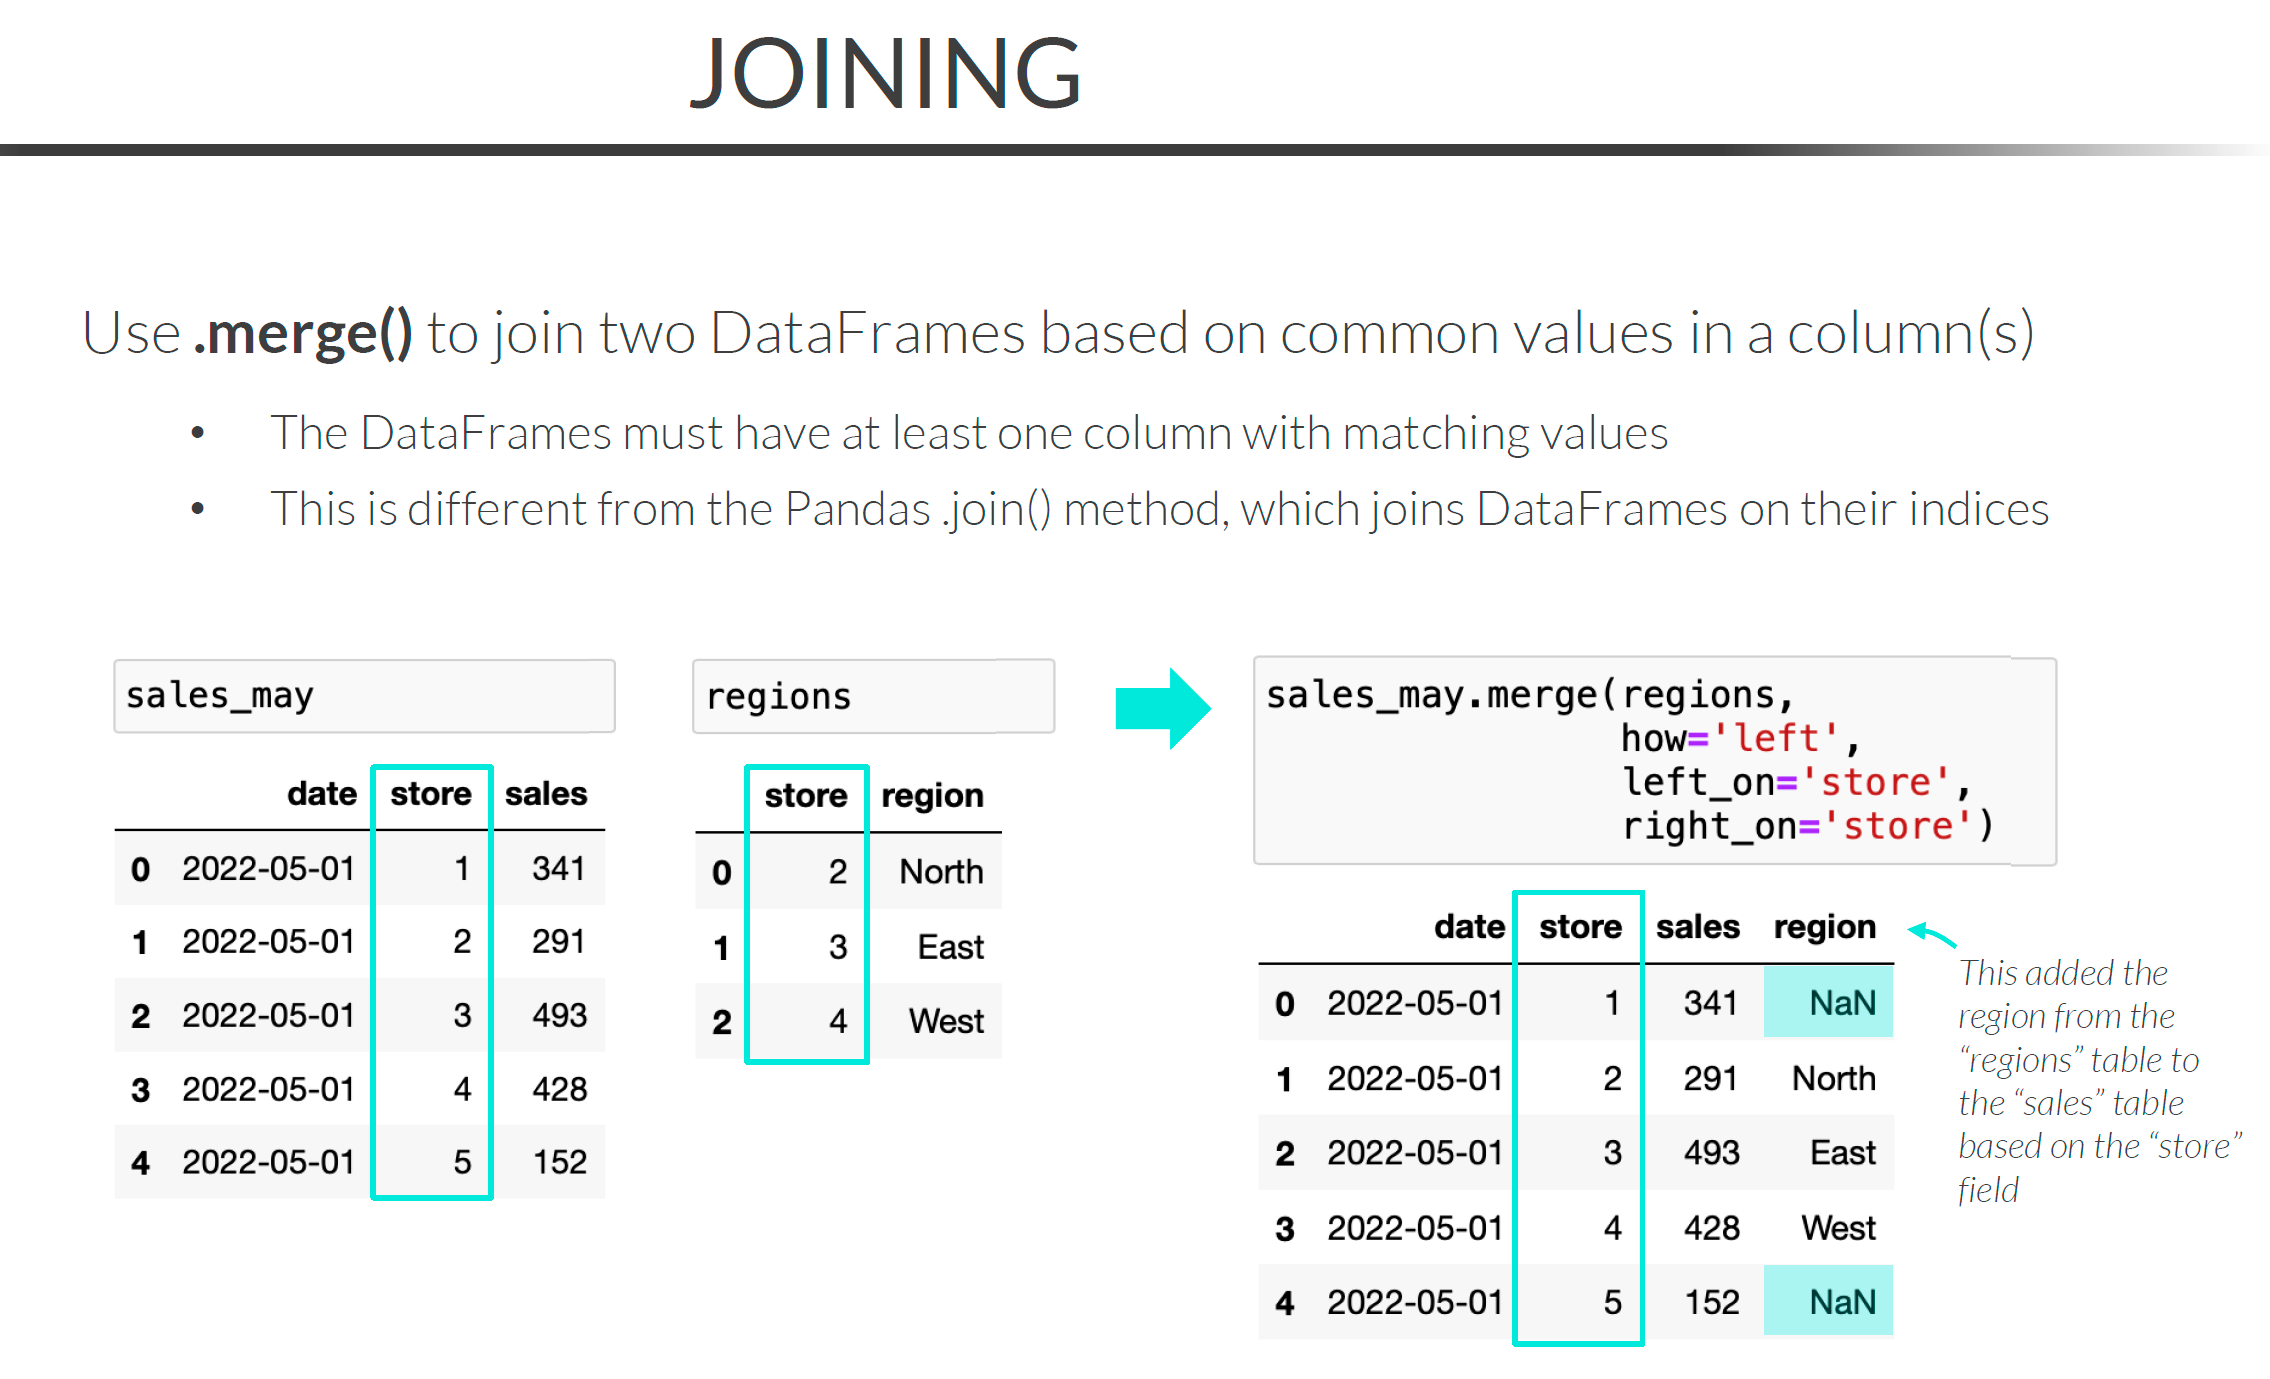

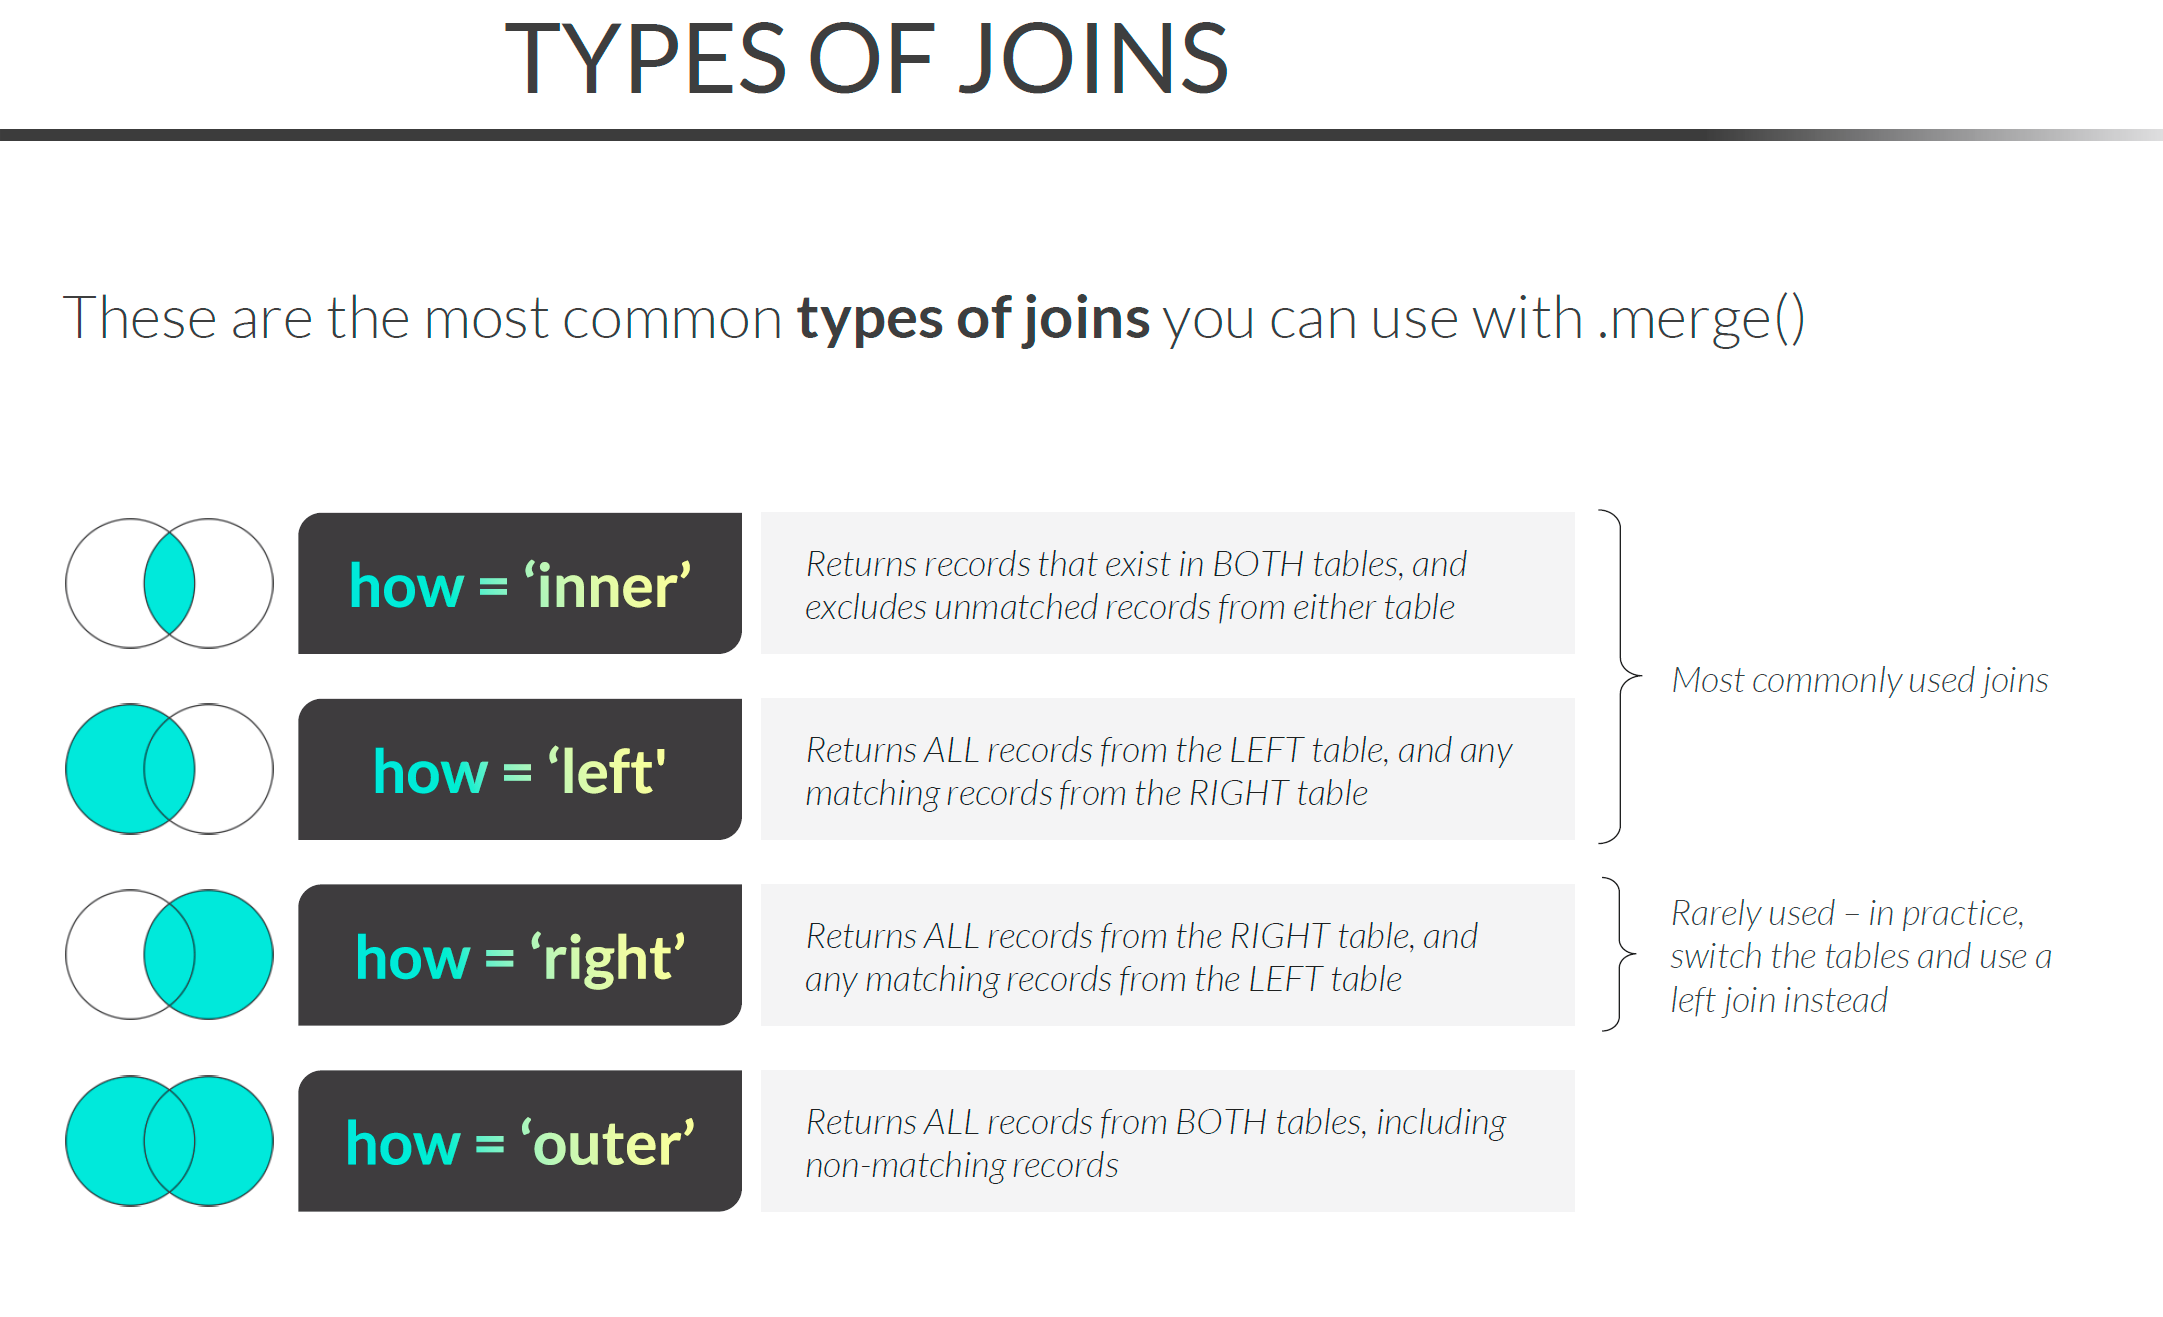

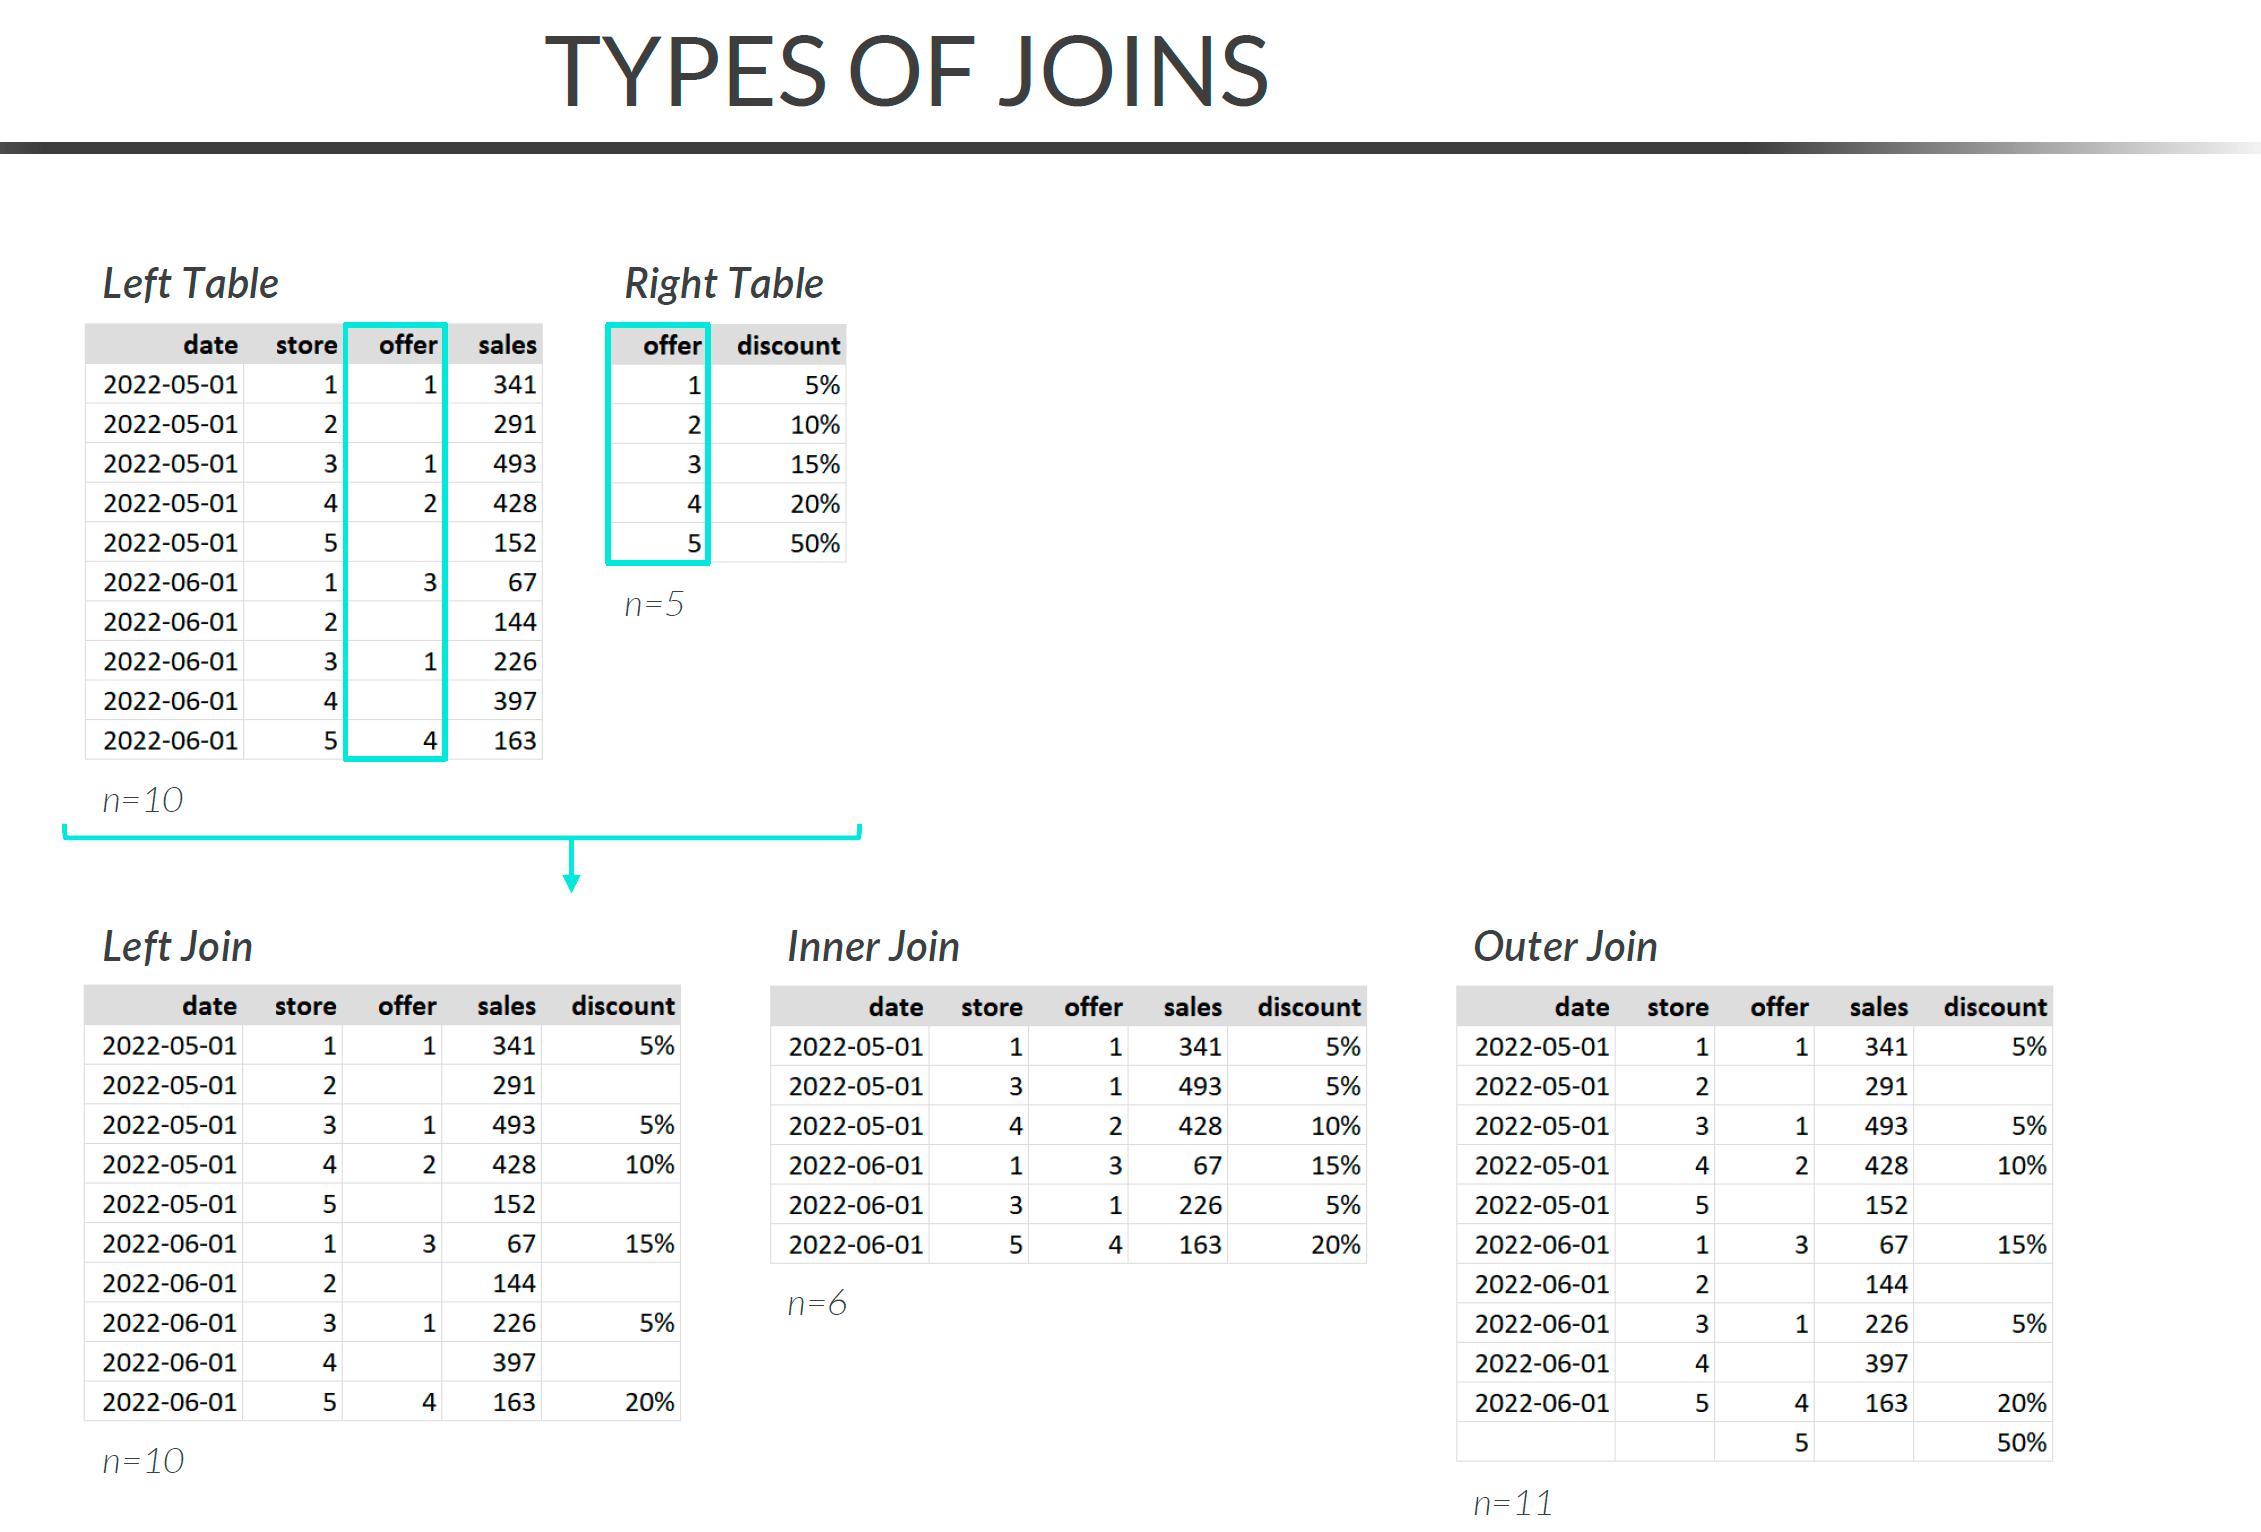

# ตัวอย่างการทำงานจริง

In [2]:
import pandas as pd
import numpy as np

# ตารางนักศึกษา
students = pd.DataFrame({
    "student_id": [1, 2, 3, 4],
    "name": ["Alice", "Bob", "Chai", "Dao"],
    "major": ["CE", "CE", "CE", "CE"]
})


enrollments = pd.DataFrame({
    "student_id": [1, 2, 2, 5],
    "course_id": ["C101", "C101", "C102", "C103"],
    "semester": ["2025-2", "2025-2", "2025-2", "2025-2"]
})


courses = pd.DataFrame({
    "course_id": ["C101", "C102", "C103", "C104"],
    "course_name": ["Data Structures", "Database Systems", "Computer Networks", "Intro to AI"],
    "credits": [3, 3, 3, 3]
})


grades = pd.DataFrame({
    "student_id": [1, 2, 2, 3],
    "course_id": ["C101", "C101", "C102", "C101"],
    "score": [88, 92, np.nan, 70]
})


In [3]:
students


,student_id,name,major
0,1,Alice,CE
1,2,Bob,CE
2,3,Chai,CE
3,4,Dao,CE


In [4]:
enrollments


,student_id,course_id,semester
0,1,C101,2025-2
1,2,C101,2025-2
2,2,C102,2025-2
3,5,C103,2025-2


In [5]:
courses


,course_id,course_name,credits
0,C101,Data Structures,3
1,C102,Database Systems,3
2,C103,Computer Networks,3
3,C104,Intro to AI,3


In [6]:
grades

,student_id,course_id,score
0,1,C101,88.0
1,2,C101,92.0
2,2,C102,NaN
3,3,C101,70.0


**A) INNER JOIN (ดึงเฉพาะข้อมูลที่ match กันทั้งสองฝั่ง)**

A1) รายการลงทะเบียนที่ถูกต้อง (มีนักศึกษาจริง)

In [7]:
students

,student_id,name,major
0,1,Alice,CE
1,2,Bob,CE
2,3,Chai,CE
3,4,Dao,CE


In [8]:
enrollments

,student_id,course_id,semester
0,1,C101,2025-2
1,2,C101,2025-2
2,2,C102,2025-2
3,5,C103,2025-2


In [9]:

A1 = students.merge(enrollments, on="student_id", how="inner")
A1 = A1[["student_id","name","course_id","semester"]]
A1

,student_id,name,course_id,semester
0,1,Alice,C101,2025-2
1,2,Bob,C101,2025-2
2,2,Bob,C102,2025-2


A2) จาก A1 ให้เพิ่ม course_name ด้วยการ join กับ courses

In [10]:

A2 = students.merge(enrollments, on="student_id", how="inner") \
             .merge(courses, on="course_id", how="inner")
A2

,student_id,name,major,course_id,semester,course_name,credits
0,1,Alice,CE,C101,2025-2,Data Structures,3
1,2,Bob,CE,C101,2025-2,Data Structures,3
2,2,Bob,CE,C102,2025-2,Database Systems,3


In [11]:
A2 = A2[["student_id","name","course_id","course_name","semester"]]
A2

,student_id,name,course_id,course_name,semester
0,1,Alice,C101,Data Structures,2025-2
1,2,Bob,C101,Data Structures,2025-2
2,2,Bob,C102,Database Systems,2025-2


A3) Gradebook เฉพาะคนที่ลงทะเบียนจริง

In [12]:
A3 = students.merge(enrollments, on="student_id", how="inner") \
             .merge(grades, on=["student_id","course_id"], how="inner")
A3

,student_id,name,major,course_id,semester,score
0,1,Alice,CE,C101,2025-2,88.0
1,2,Bob,CE,C101,2025-2,92.0
2,2,Bob,CE,C102,2025-2,NaN


In [13]:
A3 = A3[["student_id","name","course_id","score"]]
A3

,student_id,name,course_id,score
0,1,Alice,C101,88.0
1,2,Bob,C101,92.0
2,2,Bob,C102,NaN


# LEFT JOIN (ยึดตารางซ้ายเป็นหลัก

B1) ให้แสดงรายชื่อนักศึกษาทุกคน และเพิ่มคอลัมน์ registered ว่ามีลงทะเบียนหรือไม่

In [14]:
students

,student_id,name,major
0,1,Alice,CE
1,2,Bob,CE
2,3,Chai,CE
3,4,Dao,CE


In [15]:
enrollments

,student_id,course_id,semester
0,1,C101,2025-2
1,2,C101,2025-2
2,2,C102,2025-2
3,5,C103,2025-2


In [16]:
B1 = students.merge(enrollments, on="student_id", how="left")
B1

,student_id,name,major,course_id,semester
0,1,Alice,CE,C101,2025-2
1,2,Bob,CE,C101,2025-2
2,2,Bob,CE,C102,2025-2
3,3,Chai,CE,NaN,NaN
4,4,Dao,CE,NaN,NaN


In [17]:
B1["registered"] = ~B1["course_id"].isna()
B1

,student_id,name,major,course_id,semester,registered
0,1,Alice,CE,C101,2025-2,True
1,2,Bob,CE,C101,2025-2,True
2,2,Bob,CE,C102,2025-2,True
3,3,Chai,CE,NaN,NaN,False
4,4,Dao,CE,NaN,NaN,False


In [18]:
B1 = B1[["student_id","name","registered","course_id","semester"]]
B1

,student_id,name,registered,course_id,semester
0,1,Alice,True,C101,2025-2
1,2,Bob,True,C101,2025-2
2,2,Bob,True,C102,2025-2
3,3,Chai,False,NaN,NaN
4,4,Dao,False,NaN,NaN


B2) แสดงรายวิชาทั้งหมด + จำนวนคนลงทะเบียน (วิชาที่ไม่มีคนลงต้องเป็น 0)

In [19]:
courses

,course_id,course_name,credits
0,C101,Data Structures,3
1,C102,Database Systems,3
2,C103,Computer Networks,3
3,C104,Intro to AI,3


In [20]:
enrollments

,student_id,course_id,semester
0,1,C101,2025-2
1,2,C101,2025-2
2,2,C102,2025-2
3,5,C103,2025-2


In [21]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  4 non-null      int64 
 1   name        4 non-null      object
 2   major       4 non-null      object
dtypes: int64(1), object(2)
memory usage: 228.0+ bytes


In [22]:
tmp = courses.merge(enrollments, on="course_id", how="left")
tmp

,course_id,course_name,credits,student_id,semester
0,C101,Data Structures,3,1.0,2025-2
1,C101,Data Structures,3,2.0,2025-2
2,C102,Database Systems,3,2.0,2025-2
3,C103,Computer Networks,3,5.0,2025-2
4,C104,Intro to AI,3,NaN,NaN


In [23]:
tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   course_id    5 non-null      object 
 1   course_name  5 non-null      object 
 2   credits      5 non-null      int64  
 3   student_id   4 non-null      float64
 4   semester     4 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 332.0+ bytes


In [24]:
#groupby(["course_id","course_name"]) = รวมแถวที่เป็นวิชาเดียวกันเข้าด้วยกัน
#.agg(...) = สั่ง “สรุป” ข้อมูลในแต่ละกลุ่ม
# enrolled_count=("student_id","count") หมายถึง: สร้างคอลัมน์ใหม่ชื่อ enrolled_count ต่อจากนั้น ใช้คอลัมน์ student_id ในการนับ (count())
B3 = (tmp.groupby(["course_id","course_name"], as_index=False)
        .agg(enrolled_count=("student_id","count")))
B3

,course_id,course_name,enrolled_count
0,C101,Data Structures,2
1,C102,Database Systems,1
2,C103,Computer Networks,1
3,C104,Intro to AI,0


# RIGHT JOIN (ยึดตารางขวาเป็นหลัก: ใช้ตรวจความผิดปกติฝั่ง enrollments)

C1) ตรวจ enrollments ที่ไม่มีนักศึกษาจริง

In [25]:
students

,student_id,name,major
0,1,Alice,CE
1,2,Bob,CE
2,3,Chai,CE
3,4,Dao,CE


In [26]:
enrollments

,student_id,course_id,semester
0,1,C101,2025-2
1,2,C101,2025-2
2,2,C102,2025-2
3,5,C103,2025-2


In [27]:
C1 = students.merge(enrollments, on="student_id", how="right")
C1

,student_id,name,major,course_id,semester
0,1,Alice,CE,C101,2025-2
1,2,Bob,CE,C101,2025-2
2,2,Bob,CE,C102,2025-2
3,5,NaN,NaN,C103,2025-2


In [28]:
abnormal = C1[C1["name"].isna()].copy()
abnormal["issue"] = "missing_student_in_students"
abnormal

,student_id,name,major,course_id,semester,issue
3,5,NaN,NaN,C103,2025-2,missing_student_in_students


In [29]:
abnormal = abnormal[["student_id","course_id","semester","issue"]]
abnormal

,student_id,course_id,semester,issue
3,5,C103,2025-2,missing_student_in_students


# Outer join + indicator

In [30]:
audit = students.merge(enrollments, on="student_id", how="outer")
audit

,student_id,name,major,course_id,semester
0,1,Alice,CE,C101,2025-2
1,2,Bob,CE,C101,2025-2
2,2,Bob,CE,C102,2025-2
3,3,Chai,CE,NaN,NaN
4,4,Dao,CE,NaN,NaN
5,5,NaN,NaN,C103,2025-2


In [31]:
#indicator=True เพิ่มคอลัมน์พิเศษชื่อ _merge เพื่อบอกว่าแต่ละแถวมาจากฝั่งไหน

audit = students.merge(enrollments, on="student_id", how="outer", indicator=True)
audit



,student_id,name,major,course_id,semester,_merge
0,1,Alice,CE,C101,2025-2,both
1,2,Bob,CE,C101,2025-2,both
2,2,Bob,CE,C102,2025-2,both
3,3,Chai,CE,NaN,NaN,left_only
4,4,Dao,CE,NaN,NaN,left_only
5,5,NaN,NaN,C103,2025-2,right_only


In [32]:
left_table = pd.DataFrame({
    "student_id": [1, 2, 3, 4,5],
    "name": ["Alice", "Bob", "Chai", "Dao","Tanapat"],
    "major": ["CE", "CE", "CE", "CE","CIVIL"]
})
left_table

,student_id,name,major
0,1,Alice,CE
1,2,Bob,CE
2,3,Chai,CE
3,4,Dao,CE
4,5,Tanapat,CIVIL


In [33]:
right_table = pd.DataFrame({
    "student_id": [1, 2, 5],
    "course_id": ["C101", "C101", "C103"],
    "semester": ["2025-2", "2025-2", "2025-2"]
})
right_table

,student_id,course_id,semester
0,1,C101,2025-2
1,2,C101,2025-2
2,5,C103,2025-2


In [34]:
#จากตาราง 1.left_table และ 2.right_table ต้องการ ทำ right join ที่ให้ยึดตารางที่ 2 เป็นหลัก จะใช้คำสั่งไหน

In [35]:
left_table.merge(right_table, how='right')

,student_id,name,major,course_id,semester
0,1,Alice,CE,C101,2025-2
1,2,Bob,CE,C101,2025-2
2,5,Tanapat,CIVIL,C103,2025-2


In [36]:
left_table

,student_id,name,major
0,1,Alice,CE
1,2,Bob,CE
2,3,Chai,CE
3,4,Dao,CE
4,5,Tanapat,CIVIL


In [37]:
right_table

,student_id,course_id,semester
0,1,C101,2025-2
1,2,C101,2025-2
2,5,C103,2025-2


In [38]:
right_table.merge(left_table, how='right')

,student_id,course_id,semester,name,major
0,1,C101,2025-2,Alice,CE
1,2,C101,2025-2,Bob,CE
2,3,NaN,NaN,Chai,CE
3,4,NaN,NaN,Dao,CE
4,5,C103,2025-2,Tanapat,CIVIL
